In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import AnchoredText

In [178]:
train_data = pd.read_csv("data/training_set.csv")
test_data = pd.read_csv("data/test_set.csv")
zuo_data = pd.read_csv("data/zuo_data.csv")

In [179]:
train_pred = pd.read_csv("training_set_predictions.csv")
test_pred = pd.read_csv("test_set_predictions.csv")
zuo_pred = pd.read_csv("zuo_data_predictions.csv")

In [180]:
pred_properties = ["Low shear visc.", "High shear visc.", "Toughness", "Stress at break", "Strain at break"]
data_properties = ["Low shear visc", "High shear visc", "Toughness", "Stress at break", "Strain at break"]

In [181]:
all_errors = []
for i in range(len(pred_properties)):
    train_err = np.nanmedian(
        abs(np.exp(list(train_pred[pred_properties[i]])) 
            - np.exp(list(train_data[data_properties[i]])))
        /np.exp(list(train_data[data_properties[i]])))
    test_err = np.nanmedian(
        abs(np.exp(list(test_pred[pred_properties[i]])) 
            - np.exp(list(test_data[data_properties[i]])))
        /np.exp(list(test_data[data_properties[i]])))
    zuo_err = np.nanmedian(
        abs(np.exp(list(zuo_pred[pred_properties[i]])) 
            - np.exp(list(zuo_data[data_properties[i]])))
        /np.exp(list(zuo_data[data_properties[i]])))
    all_errors.append([train_err, test_err, zuo_err])

In [182]:
def corr_plot(data1, data2, data3, data4, data5, data6, error, prop, plot_name=None):
    fig, ax = plt.subplots()
    x1 = data1[pred_properties[prop]]
    x2 = data3[pred_properties[prop]]
    x3 = data5[pred_properties[prop]]
    y1 = data2[data_properties[prop]]
    y2 = data4[data_properties[prop]]
    y3 = data6[data_properties[prop]]
    all_x = list(x1) + list(x2) + list(x3)
    all_y = list(y1) + list(y2) + list(y3)
    ax.scatter(x1, y1, label='train')
    ax.scatter(x2, y2, c='orange', label='test')
    ax.scatter(x3, y3, c='green', label='Zuo')
    ax.plot([math.floor(min(all_x)),math.ceil(max(all_x))], [math.floor(min(all_x)),math.ceil(max(all_x))], c='black')
    plt.xlabel("Predicted")
    plt.ylabel("Measured")
    plt.title(pred_properties[prop])
    plt.legend()
    error_text = AnchoredText("Med. APE Train = "+f"{100*error[prop][0]:.2f}"+"%"
                              +"\nMed. APE test ="+f"{100*error[prop][1]:.2f}"+"%"
                              +"\nMed. APE Zuo ="+f"{100*error[prop][2]:.2f}"+"%", loc="lower right")
    ax.add_artist(error_text)
    if plot_name is not None:
        plt.savefig(plot_name+"_"+data_properties[prop].replace(" ","_")+"_correlation_plot.png")
    plt.show()

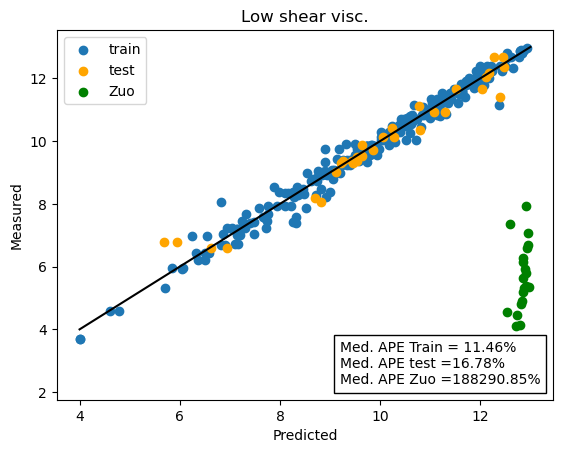

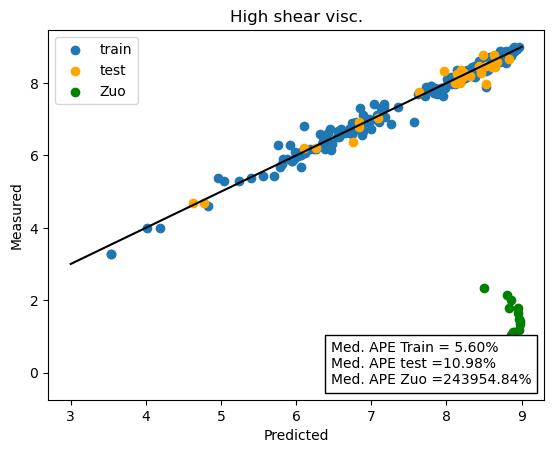

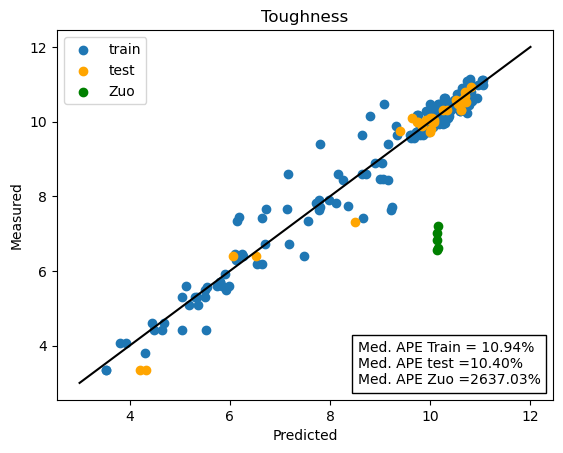

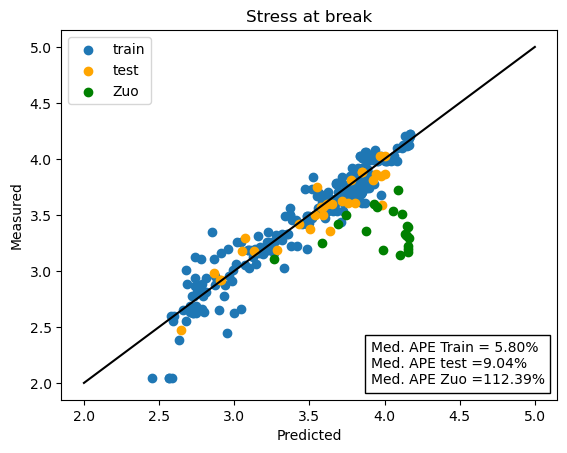

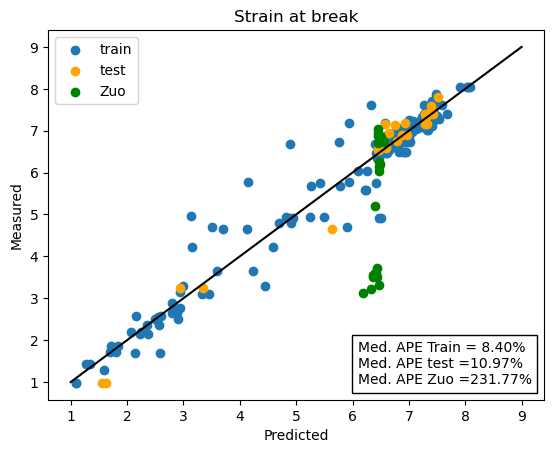

In [183]:
for i in range(len(pred_properties)):
    corr_plot(train_pred, train_data, test_pred, test_data, zuo_pred, zuo_data, all_errors, i, "no_zuo_data")